Implementing DC-DC Cuk converter outlined in the paper: 
"Data-driven model reduction by moment matching for linear and nonlinear systems" 

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


The given input function is: 
\begin{equation}
u(t) = \max \left( 0.15, \frac{1}{2} \left(\omega_1 \omega_2 + \omega_1 ^ 3 + \frac{1}{2}\right) \right)
\end{equation}

\begin{equation}
\omega_1 = 0.15 \sin(75t)
\end{equation}

\begin{equation}
\omega_2 = 0.15 ( 75 \cos(75t) )
\end{equation}

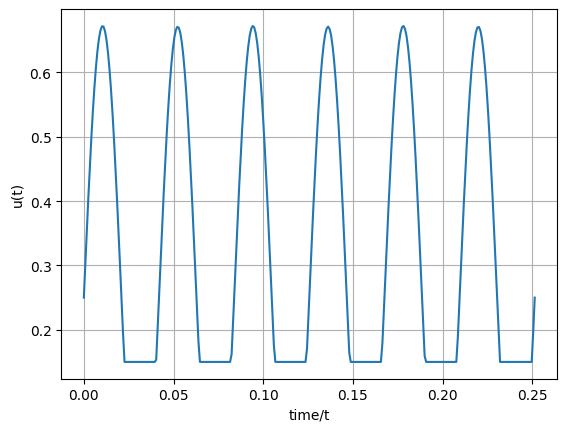

In [34]:
def u(t):
    omega1 = 0.15* np.sin(75*t)
    omega2 = 0.15* 75 * np.cos(75*t)

    func = (0.5 * ( omega1 * omega2 + omega1 ** 3 + 0.5))

    return np.where( func < 0.15, 0.15, func)

T = np.linspace(0, (6*np.pi) / 75, 300)
U = u(T)

plt.plot(T, U)
plt.grid(True)
plt.ylabel("u(t)")
plt.xlabel("time/t")
plt.show()





The averaged model of the Cuk converter is: 
yadayada


C:\Users\yoonj\AppData\Local\Temp\ipykernel_26492\2537751746.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


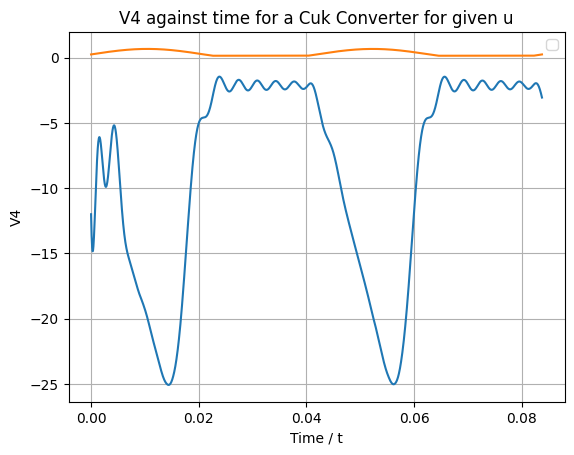

In [38]:
L1 = 10.0e-3
C2 = 22.0e-6
L3 = 10.0e-3
C4 = 22.9e-6
G = 0.0447
E = 12.0

def Cukconverter(t, x):
    x1, x2, x3, x4 = x
    u_val = u(t)

    dx1 = ( -(1.0 - u_val)*x2 + E) / L1
    dx2 = ( (1.0 - u_val ) * x1 + u_val*x3) / C2
    dx3 = (-u_val * x2 - x4) / L3
    dx4 = ( x3 - G*x4) / C4

    return [dx1, dx2, dx3, dx4]

x0 = [0.5, 10.0, -1, -12.0]
t_span = (0, (2 * np.pi) / 75)
t_eval = np.linspace(t_span[0], t_span[1], 2500)

# Solve
sol = solve_ivp(Cukconverter, t_span, x0, t_eval=t_eval)

T_list = sol.t
v4_list = sol.y[3]  # x4

plt.plot(T_list, v4_list)
plt.plot(T_list, u(T_list))
plt.grid(True)
plt.legend()
plt.xlabel("Time / t")
plt.ylabel("V4")
plt.title("V4 against time for a Cuk Converter for given u")
plt.show()




REDUCED ORDER MODEL

Implementing Algorithm 2

In [ ]:
# Let k be a sufficiently large integer. Select eta > 0
# sufficiently small. Select w geq v
# 1. Construct Uks and Gammaks matrices


Step 1. Constructing $ \widetilde{U_k} $ and $ \widetilde{\Gamma_k}$ matrices

To construct $ \widetilde{U_k} $ we have to choose a set of basis functions. We can represent this set as a vector:
\begin{equation}
\Omega = 
\begin{bmatrix}
\phi(\omega(t)) & \phi_2 (\omega(t)) & \cdots & \phi_N(\omega(t))
\end{bmatrix}
\end{equation}
Then, the matrix $ \widetilde{U_k} $ is: 
\begin{equation}
\widetilde{U_k} = 
\begin{bmatrix}
\phi_1(\omega(t_{k-w+1})) & \phi_2 (\omega(t_{k-w+1})) & \cdots & \phi_N(\omega(t_{k-w+1})) \\
\cdots \\
\phi_1(\omega(t_{k})) & \phi_2 (\omega(t_{k})) & \cdots & \phi_N(\omega(t_{k}))
\end{bmatrix}
\end{equation}

In [57]:
# For the specific case given in the paper
def omega(t):
    return 0.15* np.sin(75*t), 0.15* 75 * np.cos(75*t)


# Set of basis functions acting on omega calculated at t
# 5th order polynomials, in terms of the components of omega
def bigOmega(t, omega):
    o1, o2 = omega(t)

    # Define the basis terms more cleanly
    phi = [(i, j) for i in range(6) for j in range(6) if i + j > 0 and i <= 5 and j <= 5]

    Om = np.array([1] + [o1**i * o2**j for i, j in phi])
    return Om

t = np.pi
print(bigOmega(t, omega))

[ 1.00000000e+00 -1.12500000e+01  1.26562500e+02 -1.42382812e+03
  1.60180664e+04 -1.80203247e+05  1.91063470e-15 -2.14946404e-14
  2.41814704e-13 -2.72041542e-12  3.06046735e-11 -3.44302577e-10
  3.65052496e-30 -4.10684058e-29  4.62019565e-28 -5.19772011e-27
  5.84743512e-26 -6.57836451e-25  6.97481967e-45 -7.84667212e-44
  8.82750614e-43 -9.93094441e-42  1.11723125e-40 -1.25688515e-39
  1.33263325e-59 -1.49921240e-58  1.68661396e-57 -1.89744070e-56
  2.13462079e-55 -2.40144839e-54  2.54617533e-74 -2.86444724e-73
  3.22250315e-72 -3.62531604e-71  4.07848055e-70 -4.58829062e-69]
